# 🚀 Practice Day 19

**📅 Date:** 2026-09-30  
**📁 Category:** Phase 2 · Pandas 심화(GroupBy&Pivot) (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Practice grouping and cross-tabulating data with groupby() and pivot_table() across two dimensions at once
  (groupby()와 pivot_table()로 두 개의 차원을 동시에 교차분석하는 연습)
- Find which location and which menu category drive the most revenue, and where they intersect
  (매출을 가장 많이 견인하는 지점과 메뉴 카테고리, 그리고 그 둘이 만나는 지점 찾기)

---
# 📂 Dataset

**Dataset Name:** Urban Table Restaurant Chain — Weekly Orders by Location & Category (Q1) / Urban Table — 지점별·메뉴 카테고리별 주간 주문 데이터 (Q1)

**Source:** Synthetically generated for practice / 실습을 위해 코드로 생성한 가상 데이터

**Description:** One quarter (12 weeks) of weekly order counts and revenue for a 6-location casual dining chain in New York City (Midtown, Williamsburg, Astoria, Chelsea, Greenwich Village, Forest Hills), with revenue in USD, broken down by 4 menu categories (Appetizers, Mains, Desserts, Beverages). 288 rows total (6 locations × 4 categories × 12 weeks), clean — no missing values or duplicates. The focus is building single-dimension groupby summaries and a location × category pivot table.
(뉴욕시 캐주얼 다이닝 체인 6개 지점(Midtown, Williamsburg, Astoria, Chelsea, Greenwich Village, Forest Hills)에서 12주(1분기) 동안 4개 메뉴 카테고리(Appetizers/Mains/Desserts/Beverages)별로 집계된 주간 주문건수와 매출(USD) 데이터입니다. 총 288행(6지점×4카테고리×12주), 결측치·중복 없이 깨끗합니다. groupby로 지점별·카테고리별 집계를, pivot_table로 지점×카테고리 교차표를 만드는 데 초점을 둡니다.)

## Dataset Preview

In [31]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

# --- Generate weekly orders for a 6-location NYC restaurant chain, by menu category (revenue in USD) ---
locations = ['Midtown', 'Williamsburg', 'Astoria', 'Chelsea', 'Greenwich Village', 'Forest Hills']
location_mult = {'Midtown': 1.35, 'Williamsburg': 1.0, 'Astoria': 0.85, 'Chelsea': 1.15, 'Greenwich Village': 0.75, 'Forest Hills': 0.65}

categories = ['Appetizers', 'Mains', 'Desserts', 'Beverages']
base_orders = {'Appetizers': 40, 'Mains': 70, 'Desserts': 25, 'Beverages': 90}
avg_price = {'Appetizers': 9.00, 'Mains': 18.00, 'Desserts': 6.50, 'Beverages': 4.00}  # USD per order

weeks = list(range(1, 13))  # Week 1..12 (Q1)

rows = []
for loc in locations:
    for cat in categories:
        for w in weeks:
            growth = 1 + 0.006 * (w - 1)  # mild upward trend across the quarter
            noise = np.random.normal(1.0, 0.12)
            orders = base_orders[cat] * location_mult[loc] * growth * noise
            orders = max(1, int(round(orders)))
            price_noise = np.random.normal(1.0, 0.04)
            revenue = int(round(orders * avg_price[cat] * price_noise))   # whole dollars
            rows.append({'week': w, 'location': loc, 'category': cat, 'order_count': orders, 'revenue': revenue})

df = pd.DataFrame(rows)
df = df.sort_values(['week', 'location', 'category']).reset_index(drop=True)

df.head(10)


,week,location,category,order_count,revenue
0,1,Astoria,Appetizers,35,299
1,1,Astoria,Beverages,74,281
2,1,Astoria,Desserts,19,123
3,1,Astoria,Mains,54,963
4,1,Chelsea,Appetizers,48,421
5,1,Chelsea,Beverages,110,467
6,1,Chelsea,Desserts,26,167
7,1,Chelsea,Mains,88,1636
8,1,Forest Hills,Appetizers,26,225
9,1,Forest Hills,Beverages,67,271


## Dataset Information

In [32]:
# Dataset Information
df.info()
print("\nShape:", df.shape)
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   week         288 non-null    int64
 1   location     288 non-null    str  
 2   category     288 non-null    str  
 3   order_count  288 non-null    int64
 4   revenue      288 non-null    int64
dtypes: int64(3), str(2)
memory usage: 11.4 KB

Shape: (288, 5)


,week,location,category,order_count,revenue
count,288.000000,288,288,288.000000,288.000000
unique,NaN,6,4,NaN,NaN
top,NaN,Astoria,Appetizers,NaN,NaN
freq,NaN,48,72,NaN,NaN
mean,6.500000,NaN,NaN,55.781250,527.312500
std,3.458061,NaN,NaN,30.485686,454.051271
min,1.000000,NaN,NaN,12.000000,76.000000
25%,3.750000,NaN,NaN,30.000000,213.750000
50%,6.500000,NaN,NaN,49.500000,348.000000
75%,9.250000,NaN,NaN,79.250000,627.000000


---
# ❓ Business Questions

1. **(Analysis)** Which location generated the highest total revenue over the quarter, and which the lowest?
   (분기 총매출 기준 최고·최저 지점은?)
2. **(Analysis)** Which menu category generated the highest total revenue overall, and which the lowest?
   (전체 메뉴 카테고리 중 최고·최저 매출 카테고리는?)
3. **(Analysis)** When you cross-tabulate location and category, which single combination generated the most revenue — and which the least?
   (지점×카테고리로 교차분석했을 때, 가장 매출이 높은 조합과 가장 낮은 조합은?)
4. **(Visualization)** How do the six locations compare on total revenue?
   (6개 지점의 총매출을 비교하면 어떻게 보이는가?)
5. **(Visualization)** How does revenue break down across the location × category grid all at once?
   (지점×카테고리 조합별 매출은 한눈에 어떻게 보이는가?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `groupby().sum()`, `pivot_table`, `stack().idxmax()` / `idxmin()`
  (그룹별 합계, 교차표, 최댓값·최솟값의 위치)
- [ ] SQL
- [x] Matplotlib — `ax.bar`
  (막대 차트)
- [x] Other: Seaborn — `sns.heatmap`
  (히트맵)


---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0
  (결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — `week`, `order_count`, and `revenue` are int, `location` and `category` are text; no fix needed
  (week, order_count, revenue는 정수, location과 category는 텍스트. 수정 불필요)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [33]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
week           0
location       0
category       0
order_count    0
revenue        0
dtype: int64

Duplicate rows: 0

Dtypes
week           int64
location         str
category         str
order_count    int64
revenue        int64
dtype: object

Column names
['week', 'location', 'category', 'order_count', 'revenue']

Text columns — unique counts
location    6
category    4
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** Which location generated the highest total revenue over the quarter, and which the lowest? (분기 총매출 기준 최고·최저 지점은?)

**Result:** **Midtown** generated the highest total revenue (**$34,526**), and **Forest Hills** the lowest (**$16,510**).
(분기 총매출 최고는 Midtown($34,526), 최저는 Forest Hills($16,510))

**Insight:** Midtown's quarterly revenue is about **2.1** times Forest Hills'. The six locations step down steadily from Midtown to Forest Hills, with no tie.
(Midtown의 분기 매출은 Forest Hills의 약 2.1배. 여섯 지점은 Midtown에서 Forest Hills까지 동점 없이 계단식으로 내려감)

In [34]:
# Question 1: total revenue by location
# Hint: df.groupby('location')['revenue'].sum().sort_values()

df.groupby('location')['revenue'].sum().sort_values(ascending=False)

location
Midtown              34526
Chelsea              31741
Williamsburg         26105
Astoria              22648
Greenwich Village    20336
Forest Hills         16510
Name: revenue, dtype: int64

## Question 2

**Question:** Which menu category generated the highest total revenue overall, and which the lowest? (최고·최저 매출 카테고리는?)

**Result:** **Mains** generated the highest total revenue (**$88,694**), and **Desserts** the lowest (**$11,466**).
(최고 매출 카테고리는 Mains($88,694), 최저는 Desserts($11,466))

**Insight:** Mains alone is about **58%** of total quarterly revenue, and it is about **7.7** times Desserts. Appetizers (**$25,739**) and Beverages (**$25,967**) are almost equal.
(Mains 하나만 분기 전체 매출의 약 58%이고 Desserts의 약 7.7배. Appetizers($25,739)와 Beverages($25,967)는 거의 같음)

In [35]:
# Question 2: total revenue by category
# Hint: df.groupby('category')['revenue'].sum().sort_values()
df.groupby('category')['revenue'].sum().sort_values(ascending=False)

category
Mains         88694
Beverages     25967
Appetizers    25739
Desserts      11466
Name: revenue, dtype: int64

## Question 3

**Question:** When you cross-tabulate location and category, which single combination generated the most revenue — and which the least? (지점×카테고리 교차분석에서 최고·최저 조합은?)

**Result:** **Midtown × Mains** generated the most revenue (**$19,978**), and **Forest Hills × Desserts** the least (**$1,294**).
(가장 높은 조합은 Midtown × Mains($19,978), 가장 낮은 조합은 Forest Hills × Desserts($1,294))

**Insight:** The best and worst cells are the meeting point of Q1 and Q2: the top location with the top category, and the bottom location with the bottom category. The top cell is about **15** times the bottom cell.
(최고·최저 칸은 Q1과 Q2가 만나는 지점: 최고 지점과 최고 카테고리, 최저 지점과 최저 카테고리의 조합. 최고 칸은 최저 칸의 약 15배)

In [36]:
# Question 3: location x category cross-tab
# Hint: df.pivot_table(index='location', columns='category', values='revenue', aggfunc='sum')
pivot = df.pivot_table(index='location', columns='category', values='revenue', aggfunc='sum')

display(pivot)
print(pivot.max().max())
print(pivot.min().min())
print(pivot.stack().idxmax())
print(pivot.stack().idxmin())

category,Appetizers,Beverages,Desserts,Mains
location,,,,
Astoria,3954,3939,1667,13088
Chelsea,5299,5391,2232,18819
Forest Hills,2850,2917,1294,9449
Greenwich Village,3218,3475,1446,12197
Midtown,5952,5851,2745,19978
Williamsburg,4466,4394,2082,15163


19978
1294
('Midtown', 'Mains')
('Forest Hills', 'Desserts')


---
# 📈 Visualization

**Chart 1:** Bar chart — total revenue by location (막대그래프: 지점별 총매출)

*Interpretation:* The bars step down from left to right: Midtown is the tallest (about **$34.5K**) and Forest Hills is the shortest (about **$16.5K**), about half of Midtown. Chelsea is close behind Midtown (about **$31.7K**), and the other three locations sit between them.
(막대는 왼쪽에서 오른쪽으로 내려감: Midtown이 가장 높고(약 $34.5K) Forest Hills가 가장 낮음(약 $16.5K, Midtown의 약 절반). Chelsea(약 $31.7K)는 Midtown 바로 뒤이고 나머지 세 지점은 그 사이)

---

**Chart 2:** Heatmap — revenue by location × category (히트맵: 지점×카테고리별 매출)

*Interpretation:* The Mains column is the darkest in every row, and the Desserts column is the lightest in every row. The single darkest cell is **Midtown × Mains** (about **$20.0K**) and the single lightest cell is **Forest Hills × Desserts** (about **$1.3K**).
(Mains 열이 모든 행에서 가장 진하고 Desserts 열이 모든 행에서 가장 옅음. 가장 진한 칸은 Midtown × Mains(약 $20.0K), 가장 옅은 칸은 Forest Hills × Desserts(약 $1.3K))

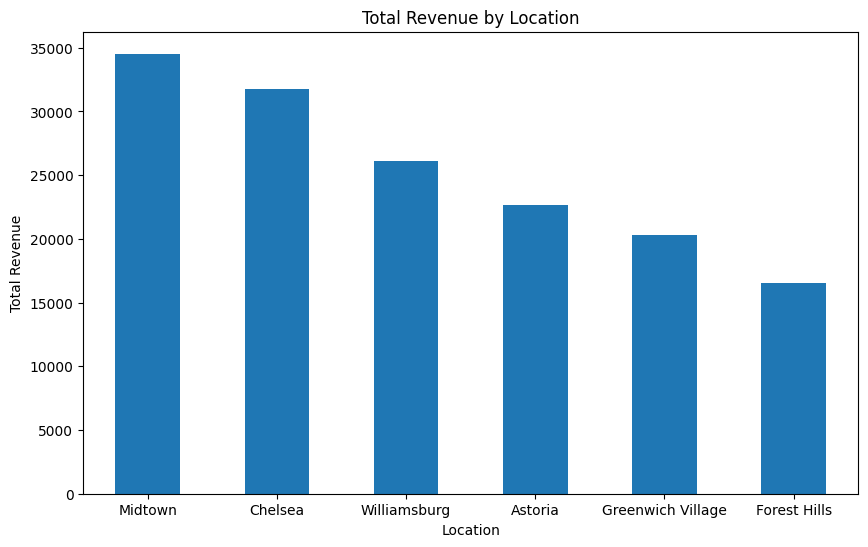

<Axes: xlabel='category', ylabel='location'>

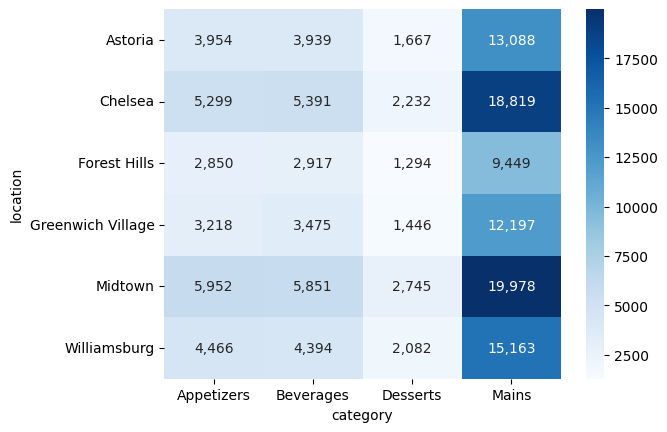

In [37]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: total revenue by location (bar)
fig, ax = plt.subplots(figsize=(10, 6))
df.groupby('location')['revenue'].sum().sort_values(ascending=False).plot(kind='bar', ax=ax, rot=0)
ax.set_title('Total Revenue by Location')
ax.set_xlabel('Location')
ax.set_ylabel('Total Revenue')
plt.show()

# Chart 2: location x category revenue (heatmap)
pivot = df.pivot_table(index='location', columns='category', values='revenue', aggfunc='sum')
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='Blues')


---
# 💼 Business Insights
**What did I discover?**

- Midtown leads the quarter (**$34,526**) and Forest Hills is last (**$16,510**), about half of Midtown.
  (분기 매출은 Midtown이 1위($34,526)이고 Forest Hills가 꼴찌($16,510)로 Midtown의 약 절반)
- Mains is about **58%** of all revenue (**$88,694**), while Desserts is the smallest category (**$11,466**).
  (Mains가 전체 매출의 약 58%($88,694)이고 Desserts가 가장 작은 카테고리($11,466))
- The single best cell is Midtown × Mains (**$19,978**) and the single worst is Forest Hills × Desserts (**$1,294**), about **15** times apart.
  (가장 좋은 칸은 Midtown × Mains($19,978), 가장 나쁜 칸은 Forest Hills × Desserts($1,294)로 약 15배 차이)
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Protect the Mains menu first, because it is about **58%** of revenue at every location.
   (Mains 메뉴를 최우선으로 지키기. 모든 지점에서 매출의 약 58%를 차지하기 때문)
2. Look at Forest Hills for ways to grow, because it is about half of Midtown's revenue.
   (Forest Hills의 성장 방법을 살펴보기. Midtown 매출의 약 절반이기 때문)
3. Test dessert promotions at the lower-revenue locations, where the Desserts cell is the smallest in every row.
   (매출이 낮은 지점에서 디저트 프로모션을 시험. 모든 행에서 Desserts 칸이 가장 작기 때문)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- I thought `groupby('location').sum()` was not the quarterly total, but the data only covers 12 weeks, so the sum is the quarter.
  (groupby('location').sum()이 분기 총매출이 아니라고 생각했지만 데이터가 12주뿐이라 그 합계가 분기 매출)
- I was going to find the best and worst cells by eye. `stack().idxmax()` and `idxmin()` give the combination directly.
  (최고·최저 칸을 눈으로 찾으려 했음. stack().idxmax()와 idxmin()이 조합을 바로 알려 줌)
- I left the y-axis label of Chart 1 without the unit. It should say USD.
  (Chart 1의 y축 라벨에 단위를 안 붙임. USD라고 써야 함)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- `groupby().sum()` answers one dimension (location or category), and `pivot_table` answers both at once.
  (groupby().sum()은 한 차원(지점 또는 카테고리)에, pivot_table은 두 차원에 동시에 답함)
- `pivot.max().max()` gives the biggest value, and `pivot.stack().idxmax()` gives the row and column it sits in.
  (pivot.max().max()는 가장 큰 값을, pivot.stack().idxmax()는 그 값이 있는 행과 열을 알려 줌)
- A heatmap makes the same pattern obvious: the darkest column and the lightest column match the highest and lowest categories.
  (히트맵은 같은 패턴을 한눈에 보여 줌. 가장 진한 열과 가장 옅은 열이 최고·최저 카테고리와 일치)
  

---
# 🧠 Reflection

**What was difficult?**
Finding the single best and worst cell in the pivot table.
(피벗 표에서 가장 좋은 칸과 나쁜 칸 하나를 찾는 것)

**Why?**
The table has 24 cells, and reading all of them by eye is slow and easy to get wrong.
(칸이 24개라 눈으로 다 읽으면 느리고 틀리기 쉬움)

**How did I solve it?**
Used `pivot.max().max()`, `pivot.min().min()`, and `stack().idxmax()` / `idxmin()` to get the value and its location.
(pivot.max().max(), pivot.min().min(), stack().idxmax()와 idxmin()으로 값과 위치를 구함)

**What would I do differently next time?**
Add the unit (USD) to every axis label when I draw the chart.
(차트를 그릴 때 모든 축 라벨에 단위(USD)를 붙이기)



---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★★☆☆☆  
`groupby` and `pivot_table` are clear. Finding the max and min cell needed help.  
(groupby와 pivot_table은 이해. 최댓값·최솟값 칸 찾기는 도움 필요)

**Confidence**  
★★★★★★☆☆☆☆  

**Difficulty**  
★★★★★☆☆☆☆☆  
Finding the best and worst cell in the pivot table was the hardest.  
(피벗 표에서 최고·최저 칸을 찾는 것이 제일 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 20 — SQL basics with DuckDB (Round 2/5)
  (SQL 기초(DuckDB) 복습)
  